## Loading light curves from the 2026 Roman Data Challenge

### Downloading the light curve

you will need to pip install huggingface_hub pyarrow fastparquet s3fs for this to work

In [2]:
# system imports
import os
import time
import sys
from pathlib import Path

# data access imports
from huggingface_hub import hf_hub_download
import pandas as pd


# data analysis/visualization imports
import numpy as np
import matplotlib.pyplot as plt

In [5]:
TIER = "Beginner"
EVENT_ID =  "RMDC26_000001" # example event ID for the Experienced and Beginner Tiers. 
# You will need to change this to the event you want to work with.
# Valid event IDs are from RMDC26_000001 to RMDC26_000188 for the Beginner Tier.
REPO_ID = f"RGES-PIT/{TIER}"
if TIER in ["Beginner", "Experienced"]:
    FILENAME = f"RMDC26_{TIER}_Tier_test.parquet"  # "_test" tells hugging face this is not a machine learning training set.
    local_data_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME, repo_type="dataset")
    lc_data_all = pd.read_parquet(local_data_path, engine="fastparquet", columns=["name", "bjd", "mag", "mag_err", "filt"], filters=[("filt", "==", "F146")])
    if EVENT_ID not in lc_data_all["name"].unique():
        raise ValueError(f"Event ID {EVENT_ID} not found in the Hugging Face {TIER} tier dataset.")
    lc_data = lc_data_all[lc_data_all["name"] == EVENT_ID].copy()
else:
    raise ValueError(f"Unsupported tier for alternate data access: {TIER}")

Bands found: ['F087' 'F146' 'F213']


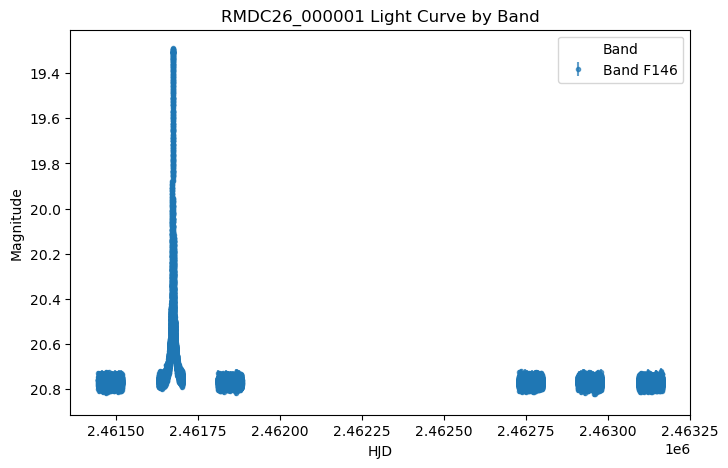

In [6]:
# Get unique bands (`observatory_code` or `filt`)
bands = np.sort(np.unique(lc_data["filt"].to_numpy()))
print(f"Bands found: {bands}")
band = 'F146'
# Plot each band separately
plt.figure(figsize=(8, 5))
#for band in bands:
mask = lc_data["filt"] == band
plt.errorbar(
    lc_data["bjd"][mask], lc_data["mag"][mask], yerr=lc_data["mag_err"][mask],
    fmt=".", label=f"Band {band}", alpha=0.7
)

plt.gca().invert_yaxis()
plt.title(f"{EVENT_ID} Light Curve by Band")
plt.xlabel("HJD")
plt.ylabel("Magnitude")
plt.legend(title="Band")
plt.show()